# Module 10 — Shadow FastAPI Integration and MPS Latency

**Question.** Can the hash-bound seed-42 LoRA-RoBERTa adapter run through the authenticated, privacy-first shadow API on Apple MPS while retaining deterministic review routing and metadata-only auditing?

**Registered gates.** MPS must be selected; startup must be at most 30 seconds; higher-method p95 in-process latency must be at most 750 ms; all 36 measured requests and required overrides must pass; no suggestion action or message-value leakage is permitted.

**Claim boundary.** This notebook reads one text-free report. The underlying run used 12 authored synthetic cases, three warm-ups and three measured repetitions. It did not access BANKING77, compute classification accuracy or validate production capacity.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "reports/service/module10-api-evaluation.json").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the project repository")


ROOT = find_repository_root(Path.cwd().resolve())
REPORT_PATH = ROOT / "reports/service/module10-api-evaluation.json"
report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
ROOT

PosixPath('/Users/coded/Downloads/IAPP-Artificial-Intelligence-Governance-Professional-AIGP-Complete-Course/AI Engineer/governed-banking-intent-router')

## 1. Evidence and runtime boundary

The runtime must prove real MPS inference while the evidence remains synthetic and explicitly non-production.

In [2]:
pd.Series({
    "Claim scope": report["claim_scope"],
    "Runtime device": report["runtime"]["selected"],
    "MPS available": report["runtime"]["mps_available"],
    "Model inference performed": report["data_boundary"]["model_inference_performed"],
    "Classification metrics computed": report["data_boundary"]["classification_metrics_computed"],
    "Official-test access": report["data_boundary"]["official_test_access"],
    "Production validation": report["data_boundary"]["production_validation"],
    "Uncertainty status": report["data_boundary"]["uncertainty_status"],
}).to_frame("Registered result")

,Registered result
Claim scope,synthetic_local_integration_not_production_val...
Runtime device,mps
MPS available,True
Model inference performed,True
Classification metrics computed,False
Official-test access,False
Production validation,False
Uncertainty status,experimental_review_only


## 2. Local startup and request latency

The measurement includes in-process HTTP handling, inference, deterministic policy evaluation and an `fsync`-backed local audit append. It is sequential and machine-specific.

In [3]:
latency = report["latency"]
latency_table = pd.Series({
    "Startup (seconds)": latency["startup_seconds"],
    "Mean (ms)": latency["mean_milliseconds"],
    "p50 (ms)": latency["p50_milliseconds"],
    "p95 (ms)": latency["p95_milliseconds"],
    "Maximum (ms)": latency["maximum_milliseconds"],
    "Registered p95 maximum (ms)": latency["registered_maximum_p95_milliseconds"],
})
latency_table.to_frame("Value")

,Value
Startup (seconds),0.9031
Mean (ms),66.9987
p50 (ms),13.3395
p95 (ms),299.2479
Maximum (ms),550.1336
Registered p95 maximum (ms),750.0000


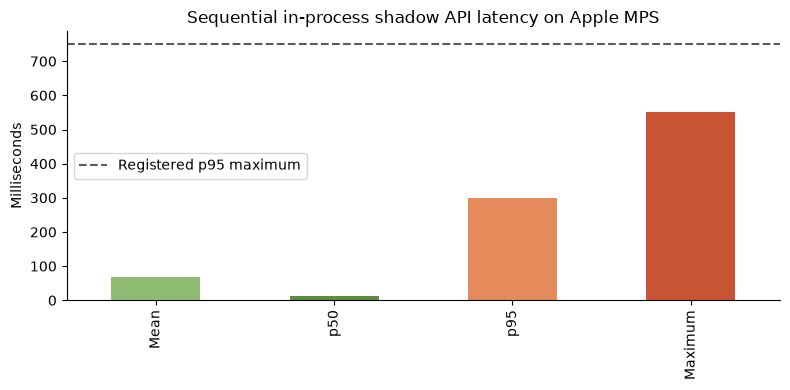

In [4]:
plot_values = pd.Series({
    "Mean": latency["mean_milliseconds"],
    "p50": latency["p50_milliseconds"],
    "p95": latency["p95_milliseconds"],
    "Maximum": latency["maximum_milliseconds"],
})
ax = plot_values.plot.bar(figsize=(8, 4), color=["#8DBB72", "#5B8E3E", "#E58B5B", "#C95433"])
ax.axhline(
    latency["registered_maximum_p95_milliseconds"],
    color="#5F5B53",
    linestyle="--",
    label="Registered p95 maximum",
)
ax.set_ylabel("Milliseconds")
ax.set_title("Sequential in-process shadow API latency on Apple MPS")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Routing and API safety

A passing latency result cannot authorize automation. The shadow schema still permits only human review and security prioritization.

In [5]:
routing = report["routing"]
api = report["api"]
pd.Series({
    "Measured requests": report["protocol"]["measured_requests"],
    "HTTP 200 responses": api["response_status_counts"].get("200", 0),
    "Human-review routes": routing["action_counts"].get("human_review", 0),
    "Security routes": routing["action_counts"].get("security_queue", 0),
    "Suggestion routes": routing["suggest_queue_count"],
    "Required override failures": len(routing["required_override_failures"]),
    "Message-value matches": api["prohibited_value_matches"],
}).to_frame("Result")

,Result
Measured requests,36
HTTP 200 responses,36
Human-review routes,30
Security routes,6
Suggestion routes,0
Required override failures,0
Message-value matches,0


In [6]:
security_checks = (
    pd.Series(api["security_boundary_checks"])
    .rename_axis("Boundary check")
    .to_frame("Passed")
)
assert security_checks["Passed"].all()
security_checks

,Passed
Boundary check,
authentication_required,True
docs_disabled,True
extra_fields_rejected,True
health_minimal,True
oversized_body_rejected,True
security_headers_present,True
untrusted_host_rejected,True


## 4. Registered acceptance decision

In [7]:
gates = pd.Series(report["acceptance_gate"]).rename_axis("Gate").to_frame("Passed")
assert gates["Passed"].all(), "A registered Module 10 gate failed"
gates

,Passed
Gate,
all_measured_http_responses_successful,True
all_passed,True
all_required_overrides_passed,True
metadata_only_api_and_audit,True
module8_uncertainty_remains_experimental,True
mps_selected,True
p95_latency_within_registered_maximum,True
restrictive_audit_permissions,True
security_boundary_checks_passed,True


## Interpretation

The real local MPS integration passed the preregistered engineering checks. Startup was below one second and p95 in-process latency stayed below the 750 ms target while every measured request produced a metadata-only audit event and no suggestion route.

This supports a narrow claim: the registered components integrate successfully on the documented Mac in sequential shadow mode. It does not establish model accuracy, production privacy performance, concurrency capacity, availability or a safe uncertainty threshold. Module 8 remains failed and experimental.